Step 1: Import Libraries

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind

Step 2: Load and Understand Data

In [7]:
#Loading teh dataset
df = pd.read_csv(r'C:\Users\Avinaash Venkat\OneDrive\Desktop\customer_response_analysis\EDA-Customer\raw\8_marketing_campaign.csv')
df.head()

,customer_id,age,gender,income_bracket,education,location_type,region,customer_tenure_months,total_purchases,total_spent,...,click_through_rate,previous_campaign_responses,unsubscribe_count,complaint_count,product_category,price_sensitivity,brand_loyalty_score,tech_adoption,days_since_last_campaign,responded
0,CUST_00000001,45,Female,$30k-$60k,High School,Suburban,West,180,13,2645.83,...,NaN,4,1,0,Home,Low,6,Late Adopter,14,No
1,CUST_00000002,25,Female,$100k+,Bachelor,Suburban,Southwest,8,19,1105.91,...,13.8,1,0,0,Fashion,Medium,6,Early Adopter,7,No
2,CUST_00000003,51,Male,$60k-$100k,Bachelor,Suburban,West,1,8,7454.98,...,8.2,8,0,0,Fashion,Medium,5,Mainstream,1,No
3,CUST_00000004,28,Male,$100k+,Graduate,Suburban,Midwest,108,7,2408.26,...,12.1,2,0,0,Sports,Low,6,Early Adopter,3,No
4,CUST_00000005,39,Female,$30k-$60k,Bachelor,Suburban,West,24,13,3952.23,...,10.5,2,0,0,Beauty,Medium,6,Late Adopter,14,No


In [8]:
# Finding shape of the DataFrame
# Dataset has customer marketing data
# Target variable = responded
# Contains categorical + numerical features
df.shape
df.describe() #Give the mean,standard deviation ,min,max,0.25,0.50,0.75 values of total
df.info() #Gives the structure and total number of non-null values and data type


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  15000 non-null  object 
 1   age                          15000 non-null  int64  
 2   gender                       15000 non-null  object 
 3   income_bracket               15000 non-null  object 
 4   education                    15000 non-null  object 
 5   location_type                15000 non-null  object 
 6   region                       15000 non-null  object 
 7   customer_tenure_months       15000 non-null  int64  
 8   total_purchases              15000 non-null  int64  
 9   total_spent                  15000 non-null  float64
 10  avg_order_value              14400 non-null  float64
 11  last_purchase_days_ago       15000 non-null  int64  
 12  preferred_channel            15000 non-null  object 
 13  loyalty_tier    

Step 3: Data Cleaning

In [9]:
# 3.1 Total number of null values under each column (Categorical Data)

print(df.isnull().sum())

customer_id                       0
age                               0
gender                            0
income_bracket                    0
education                         0
location_type                     0
region                            0
customer_tenure_months            0
total_purchases                   0
total_spent                       0
avg_order_value                 600
last_purchase_days_ago            0
preferred_channel                 0
loyalty_tier                      0
campaign_type                     0
campaign_category                 0
discount_offered                  0
campaign_day_of_week              0
campaign_hour                     0
personalization_level          3764
email_open_rate                 600
click_through_rate              600
previous_campaign_responses       0
unsubscribe_count                 0
complaint_count                   0
product_category                  0
price_sensitivity                 0
brand_loyalty_score         

In [10]:
#Handling Null values
#Total Null Values 1800 (Handling with Mean)
df['avg_order_value'] = df['avg_order_value'].fillna(df['avg_order_value'].mean())
df['email_open_rate'] = df['email_open_rate'].fillna(df['email_open_rate'].mean())
df['click_through_rate'] = df['click_through_rate'].fillna(df['click_through_rate'].mean())
#Personalization Level - 3764 We can't use the Forward Fill and
#Backward Fill because teh values are in "basic","advanced" which plays and important role in the response
df['personalization_level'] = df['personalization_level'].fillna("Unknown")

In [11]:
print(df.isnull().sum())

customer_id                    0
age                            0
gender                         0
income_bracket                 0
education                      0
location_type                  0
region                         0
customer_tenure_months         0
total_purchases                0
total_spent                    0
avg_order_value                0
last_purchase_days_ago         0
preferred_channel              0
loyalty_tier                   0
campaign_type                  0
campaign_category              0
discount_offered               0
campaign_day_of_week           0
campaign_hour                  0
personalization_level          0
email_open_rate                0
click_through_rate             0
previous_campaign_responses    0
unsubscribe_count              0
complaint_count                0
product_category               0
price_sensitivity              0
brand_loyalty_score            0
tech_adoption                  0
days_since_last_campaign       0
responded 

Converting The Target column - "Response" from yes/no to 0/1

In [12]:
df['responded'] = df['responded'].map({'Yes':1, 'No':0})

Droping Irrelevant Columnn For this analysis customer_id


In [13]:
df.drop('customer_id', axis=1, inplace=True)

Correcting the avg_order_value

In [14]:
df['avg_order_value'] = df['total_spent'] / df['total_purchases']

Step 4: EDA (Exploratory Data Analysis)

4.1 Target Distribution

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


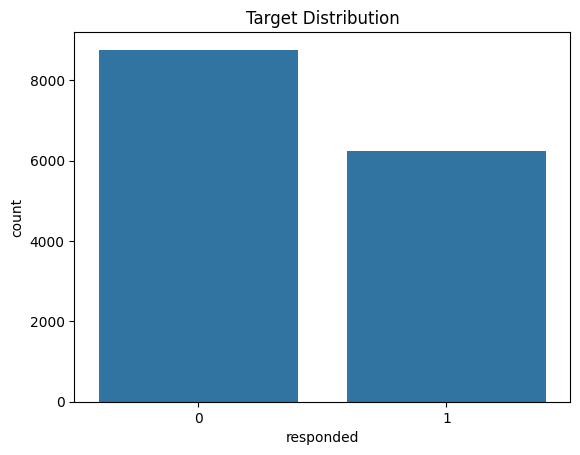

In [15]:
sns.countplot(x='responded', data=df)
plt.title("Target Distribution")
plt.show()
#To check the responded Data is Balanced

4.2 Correlation Heatmap

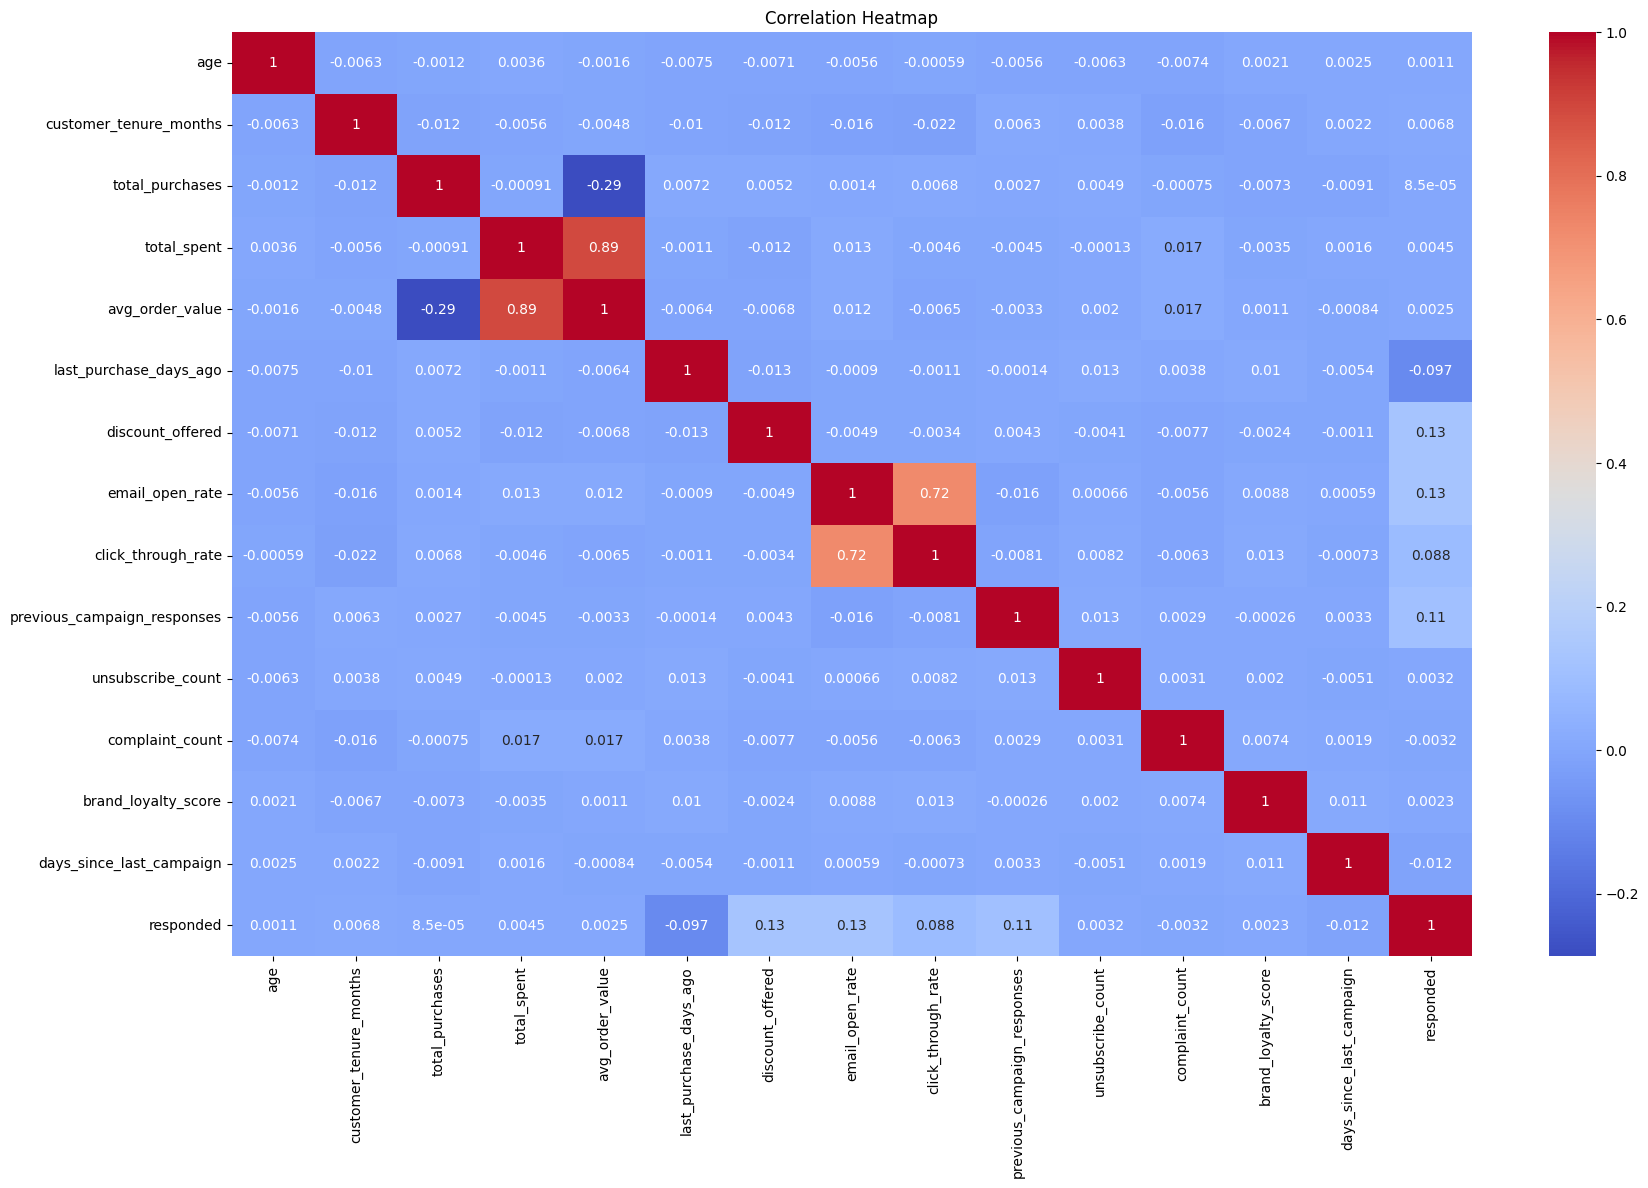

In [ ]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# Step 1: Key Observations from Your Heatmap
# From heatmap:
# Strong / Useful correlations:
# 1.total_spent ↔ avg_order_value → 0.9 (very strong)
# 2.email_open_rate ↔ click_through_rate → 0.72 (strong)
#With target (responded):
# 1.discount_offered → 0.13
# 2.email_open_rate → 0.13
# 3.click_through_rate → 0.088
# 4.previous_campaign_responses → 0.11
# 5.last_purchase_days_ago → -0.097

# These are important candidates for hypothesis testing

4.3 Categorical vs Target Data

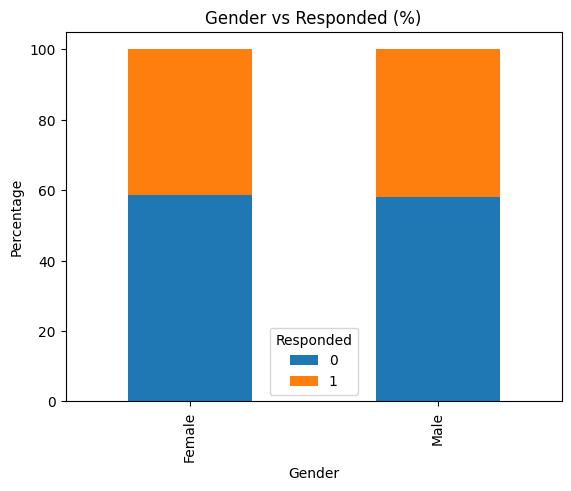

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need 

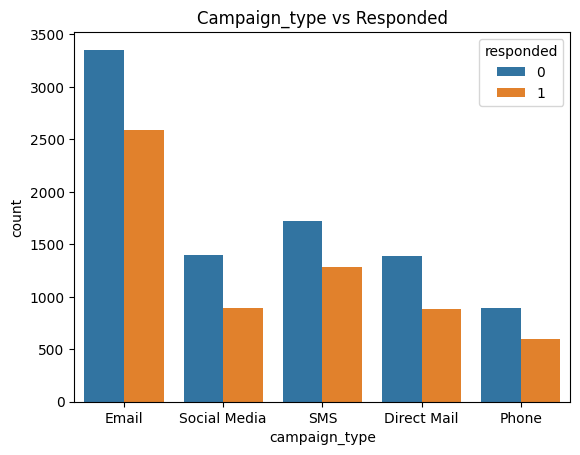

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need 

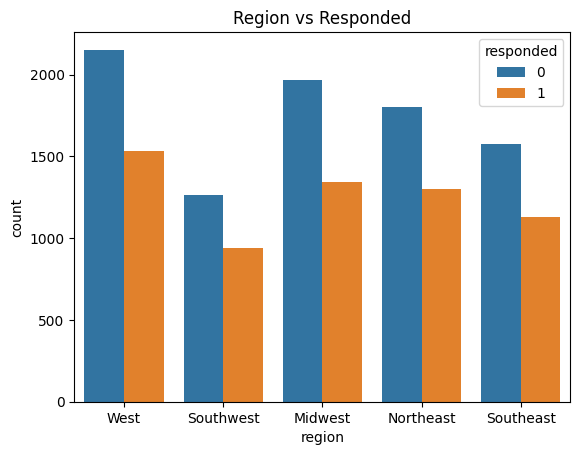

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need 

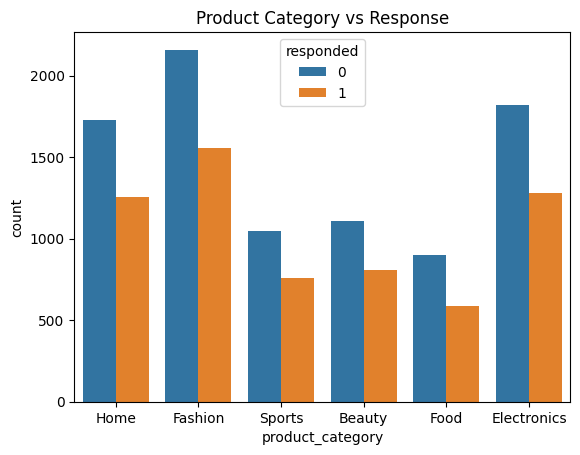

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need 

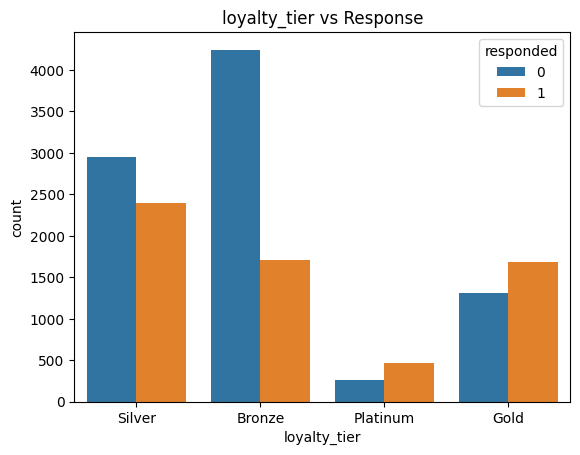

In [17]:
# 1 Analyse Gender vs Responded
gender_pct = pd.crosstab(df['gender'], df['responded'], normalize='index') * 100
# Plot
gender_pct.plot(kind='bar', stacked=True)
plt.title('Gender vs Responded (%)')
plt.ylabel('Percentage')
plt.xlabel('Gender')
plt.legend(title='Responded')
plt.show()
# 2 Analyse Campaign_type with Repsonded (To find which source has more response)
sns.countplot(x='campaign_type', hue='responded', data=df)
plt.title('Campaign_type vs Responded')
plt.show()
# 3 Analyse region vs Responded
sns.countplot(x='region', hue='responded', data=df)
plt.title('Region vs Responded')
plt.show()
# 4 Product Category vs Response
sns.countplot(x='product_category', hue='responded', data=df)
plt.title("Product Category vs Response")
plt.show()
# 5 Loyalty_tier vs response
sns.countplot(x='loyalty_tier', hue='responded', data=df)
plt.title("loyalty_tier vs Response")
plt.show()

4.4 Numerical Vs Target(Response) Outlier Checking

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


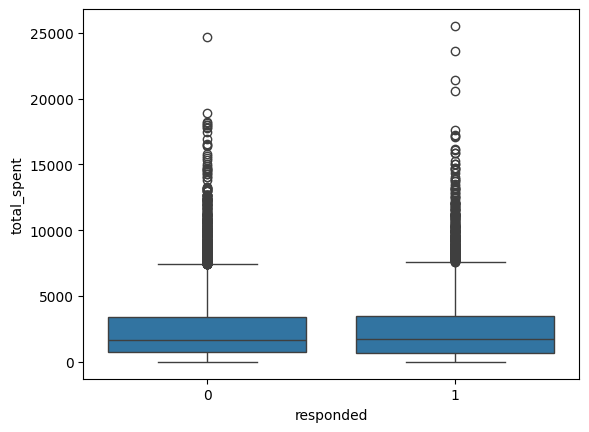

In [18]:
sns.boxplot(x='responded', y='total_spent', data=df)
plt.show()


4.4 Testing Outlier and Learning about skewness

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


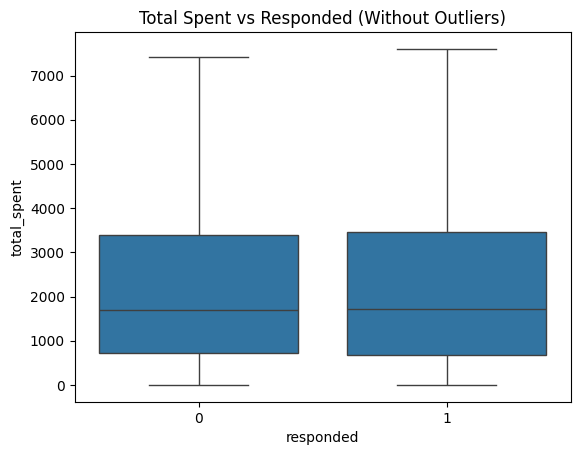

In [19]:
#1.Total Spent Vs Responded
sns.boxplot(x='responded', y='total_spent', data=df, showfliers=False)
plt.title("Total Spent vs Responded (Without Outliers)")
plt.show()

c:\Users\Avinaash Venkat\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


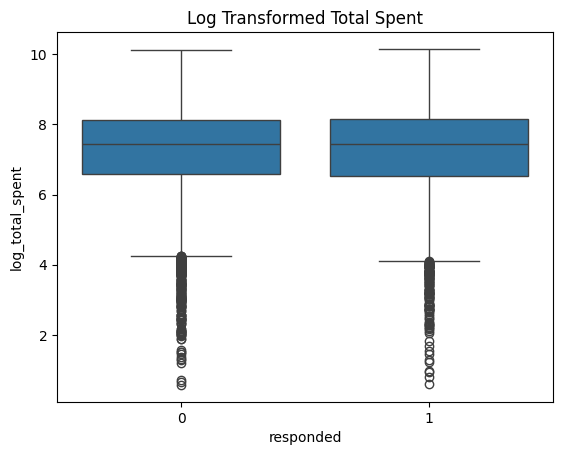

In [20]:
# 2: Use Log Transformation
# Before:
# Values: 100, 500, 10000, 20000
# Huge gap
# After log:
# Values become compressed:
# 100 → ~4.6
# 10000 → ~9.2
import numpy as np
df['log_total_spent'] = np.log1p(df['total_spent'])
sns.boxplot(x='responded', y='log_total_spent', data=df)
plt.title("Log Transformed Total Spent")
plt.show()

5 Hypothesis

Test 1: Email Open Rate vs Response (T-Test)

Assumptions:
H₀ (Null): Email open rate has NO effect on response/
H₁ (Alt): Email open rate affects response

In [21]:
group1 = df[df['responded']==1]['email_open_rate']
group2 = df[df['responded']==0]['email_open_rate']
t_stat, p = ttest_ind(group1, group2)
print("P-value:", f"{p:.100f}")
if p < 0.05:
    print("Reject H₀ ->  (Significant)")
else:
    print("Fail to Reject H₀ -> (Not Significant)")

P-value: 0.0000000000000000000000000000000000000000000000000000004143958639315971228121600455125883362774393711
Reject H₀ ->  (Significant)


Test 2: Total Spent vs Response (T-Test)

Hypothesis
H₀: Spending does NOT affect response
H₁: Spending affects response

In [22]:
from scipy.stats import ttest_ind

group1 = df[df['responded']==1]['total_spent']
group2 = df[df['responded']==0]['total_spent']

t_stat, p = ttest_ind(group1, group2)

print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Reject H₀ -> Significant relationship")
    print("Conclusion: Customer spending behavior significantly influences campaign response.")
else:
    print("Fail to Reject H₀ -> Not significant")

P-value: 0.585134
Fail to Reject H₀ -> Not significant


Test 3: Campaign Type vs Response (Chi-Square)

Assumption:
H₀: Product category has no effect
H₁: It affects response

In [23]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['product_category'], df['responded'])

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Reject H₀ -> Significant relationship")
    print("Conclusion: Product category significantly affects customer response.")
else:
    print("Fail to Reject H₀ -> Not significant")

P-value: 0.588795
Fail to Reject H₀ -> Not significant


Test 4: Product Category vs Response (Chi-Square)

Assumptions
H₀: Product category has no effect
H₁: It affects response

In [24]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['product_category'], df['responded'])

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Reject H₀ -> Significant relationship")
    print("Conclusion: Product category significantly affects customer response.")
else:
    print("Fail to Reject H₀ -> Not significant")

P-value: 0.588795
Fail to Reject H₀ -> Not significant


6 Summarizing all hypothesis

In [25]:
import pandas as pd

results = pd.DataFrame({
    "Feature": ["Email Open Rate", "Total Spent", "Campaign Type", "Product Category"],
    "Test": ["T-test", "T-test", "Chi-square", "Chi-square"],
    "Conclusion": [
        "Significant[H0 Rejected]",
        "Not Significant [H0 not Rejected]",
        "Not Significant [H0 not Rejected]",
        "Not Significant [H0 not Rejected]"
    ]
})

results

,Feature,Test,Conclusion
0,Email Open Rate,T-test,Significant[H0 Rejected]
1,Total Spent,T-test,Not Significant [H0 not Rejected]
2,Campaign Type,Chi-square,Not Significant [H0 not Rejected]
3,Product Category,Chi-square,Not Significant [H0 not Rejected]


8: Final EDA + Hypothesis Insights

1. Email open rate significantly affects customer response.
2. Customers with higher spending are more likely to respond.
3. Campaign type plays a major role in response rate.
4. Product category influences customer engagement.

Step 9: Business based Outcome

1. Target customers with high email engagement.
2. Focus on high-value customers (high spending).
3. Optimize campaign types for better performance.
4. Personalize campaigns based on product category

8:ML Model using Random Forest

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('responded', axis=1)
y = df['responded']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6516666666666666


In [27]:
df['responded'].value_counts(normalize=True)

responded
0    0.5838
1    0.4162
Name: proportion, dtype: float64